In [1]:
# 1. Устанавливаем библиотеки для работы с БД (если их ещё нет)
!pip install pandas sqlalchemy psycopg2-binary

# 2. Импортируем библиотеки
import pandas as pd
from sqlalchemy import create_engine

# 3. Данные для подключения к БД (из проекта)
db_config = {
    'user': 'praktikum_student',
    'pwd': 'Sdf4$2;d-d30pp',
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432,
    'db': 'data-analyst-afisha'
}

# 4. Формируем строку подключения
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

# 5. Создаём движок (engine)
engine = create_engine(connection_string)

# 6. Твой SQL-запрос для выгрузки (мы писали его в тренажёре)
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    service_name,
    r.region_name,
    c.city_name
FROM purchases p
INNER JOIN events e ON p.event_id = e.event_id
LEFT JOIN city c ON e.city_id = c.city_id
LEFT JOIN regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
'''

# 7. Выгружаем данные в датафрейм
df = pd.read_sql_query(query, con=engine)

# 8. Проверяем результат (первые 5 строк)
df.head()

DatabaseError: Execution failed on sql '
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    service_name,
    r.region_name,
    c.city_name
FROM purchases p
INNER JOIN events e ON p.event_id = e.event_id
LEFT JOIN city c ON e.city_id = c.city_id
LEFT JOIN regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
': (psycopg2.errors.UndefinedTable) relation "purchases" does not exist
LINE 18: FROM purchases p
              ^

[SQL: 
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt

In [2]:
# Исправленный SQL-запрос с указанием схемы afisha
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
'''

# Снова загружаем данные в датафрейм (теперь с новым запросом)
df = pd.read_sql_query(query, con=engine)

# Проверяем результат
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [3]:
# Исправленный SQL-запрос с указанием схемы afisha
query = '''
SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM (p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY p.user_id ORDER BY p.created_dt_msk)))::INTEGER AS days_since_prev,
    p.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
LEFT JOIN afisha.city c ON e.city_id = c.city_id
LEFT JOIN afisha.regions r ON c.region_id = r.region_id
WHERE p.device_type_canonical IN ('mobile', 'desktop')
  AND e.event_type_main != 'фильм'
ORDER BY p.user_id;
'''

# Снова загружаем данные в датафрейм (теперь с новым запросом)
df = pd.read_sql_query(query, con=engine)

# Проверяем результат
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [4]:
# 1. Общая информация о датафрейме (типы данных, пропуски)
df.info()

# 2. Основные статистики по числовым колонкам
df.describe()

# 3. Проверка уникальных значений в ключевых категориальных колонках
print("Уникальные типы устройств:", df['device_type_canonical'].unique())
print("Уникальные валюты:", df['currency_code'].unique())
print("Уникальные типы событий:", df['event_type_main'].unique()[:10]) # первые 10

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


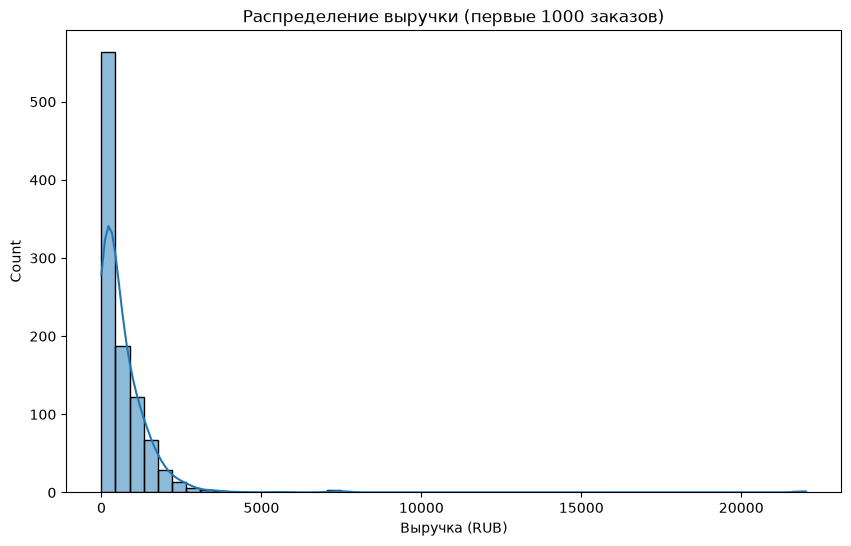

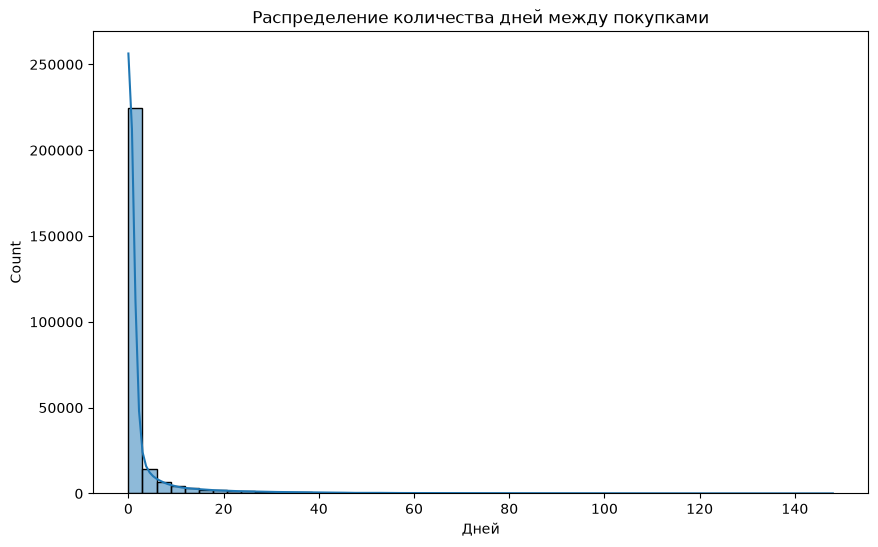

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Изучаем распределение выручки (первые 1000 заказов, чтобы увидеть паттерн)
plt.figure(figsize=(10, 6))
sns.histplot(df['revenue'].head(1000), bins=50, kde=True)
plt.title('Распределение выручки (первые 1000 заказов)')
plt.xlabel('Выручка (RUB)')
plt.show()

# 2. Смотрим на повторные покупки (сколько дней между заказами)
# Убираем NaN (первые покупки), чтобы не искажать график
days = df['days_since_prev'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(days, bins=50, kde=True)
plt.title('Распределение количества дней между покупками')
plt.xlabel('Дней')
plt.show()

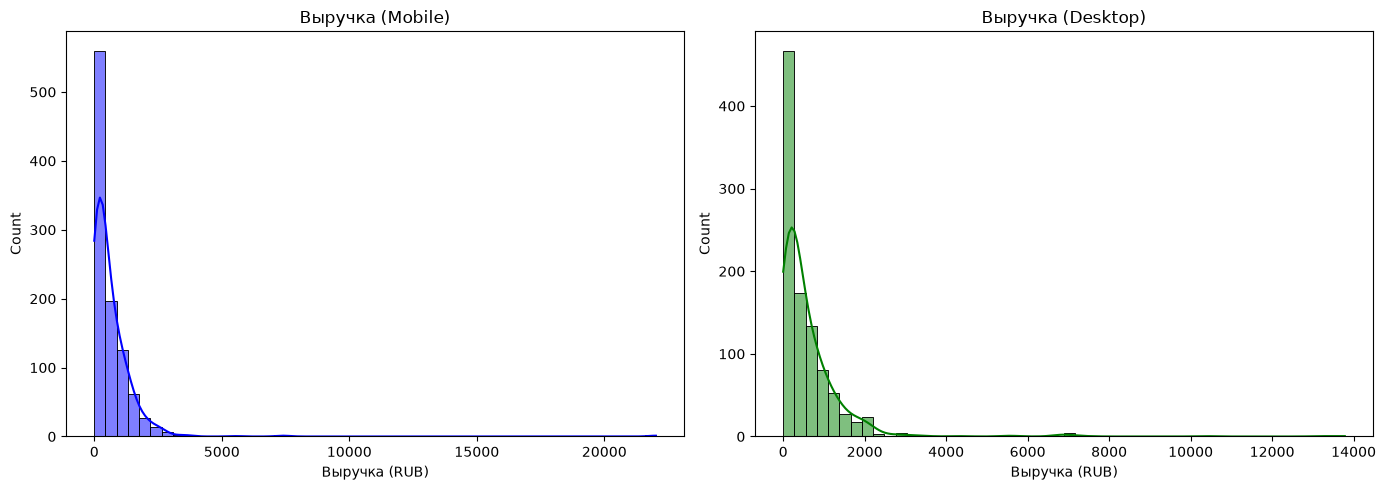

Средний чек Mobile: 606.0217881629318
Средний чек Desktop: 703.8366676416442


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Строим два графика рядом: распределение выручки для Mobile и Desktop
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График для Mobile
sns.histplot(df[df['device_type_canonical'] == 'mobile']['revenue'].head(1000), bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Выручка (Mobile)')
axes[0].set_xlabel('Выручка (RUB)')

# График для Desktop
sns.histplot(df[df['device_type_canonical'] == 'desktop']['revenue'].head(1000), bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title('Выручка (Desktop)')
axes[1].set_xlabel('Выручка (RUB)')

plt.tight_layout()
plt.show()

# Смотрим средние чеки
print("Средний чек Mobile:", df[df['device_type_canonical'] == 'mobile']['revenue'].mean())
print("Средний чек Desktop:", df[df['device_type_canonical'] == 'desktop']['revenue'].mean())

Распределение пользователей по количеству заказов:
orders_count
1        8374
2        3582
3        2176
4        1401
5         980
         ... 
3749        1
3826        1
4053        1
4368        1
10251       1
Name: count, Length: 333, dtype: int64


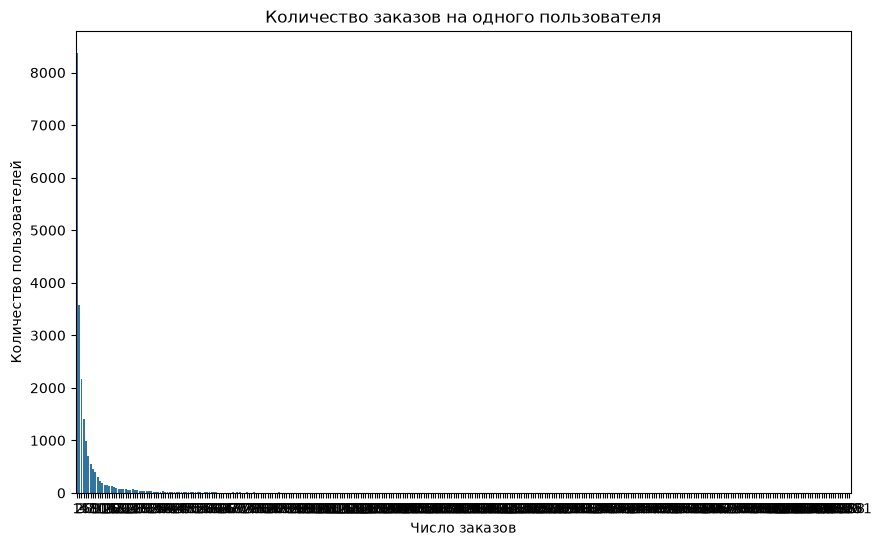

In [7]:
# 1. Считаем количество заказов на каждого пользователя
user_orders = df.groupby('user_id')['order_id'].count().reset_index()
user_orders.columns = ['user_id', 'orders_count']

# 2. Смотрим распределение (сколько пользователей купили 1 раз, 2 раза, 3+ раза)
print("Распределение пользователей по количеству заказов:")
print(user_orders['orders_count'].value_counts().sort_index())

# 3. Визуализируем это распределение
plt.figure(figsize=(10, 6))
sns.countplot(x='orders_count', data=user_orders)
plt.title('Количество заказов на одного пользователя')
plt.xlabel('Число заказов')
plt.ylabel('Количество пользователей')
plt.show()

In [8]:
# Создаем новый столбец в исходном датафрейме
# Считаем общее количество заказов для каждого пользователя
total_orders_per_user = df.groupby('user_id')['order_id'].transform('count')

# Добавляем метку: 'Returned' (если заказов > 1) или 'New' (если заказов = 1)
df['user_type'] = total_orders_per_user.apply(lambda x: 'Returned' if x > 1 else 'New')

# Смотрим, сколько у нас "Новых" и "Вернувшихся"
print(df['user_type'].value_counts())

# Сравниваем средний чек между этими группами
print("\nСредний чек (новые vs вернувшиеся):")
print(df.groupby('user_type')['revenue'].mean())

user_type
Returned    282237
New           8374
Name: count, dtype: int64

Средний чек (новые vs вернувшиеся):
user_type
New         660.917370
Returned    624.536026
Name: revenue, dtype: float64


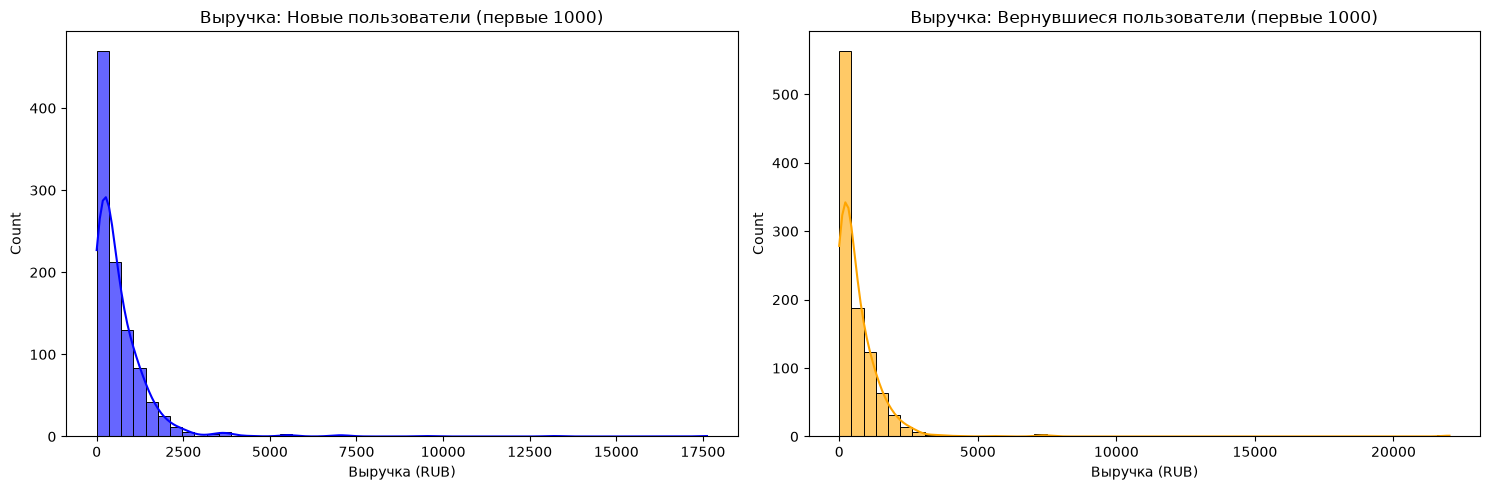

Средняя выручка по регионам (Топ-5):
region_name
Верхоречная область       5113.420788
Шанырский регион          4510.634011
Верховинская область      1570.502200
Лесоярская область        1138.773656
Озернопольская область    1062.980592
Name: revenue, dtype: float64

Средняя выручка по типам устройств:
device_type_canonical
desktop    703.836668
mobile     606.021788
Name: revenue, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем размер графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. График: распределение выручки (первые 1000 заказов для каждой группы)
sns.histplot(df[df['user_type'] == 'New']['revenue'].head(1000), bins=50, kde=True, ax=axes[0], color='blue', alpha=0.6)
sns.histplot(df[df['user_type'] == 'Returned']['revenue'].head(1000), bins=50, kde=True, ax=axes[1], color='orange', alpha=0.6)
axes[0].set_title('Выручка: Новые пользователи (первые 1000)')
axes[1].set_title('Выручка: Вернувшиеся пользователи (первые 1000)')
axes[0].set_xlabel('Выручка (RUB)')
axes[1].set_xlabel('Выручка (RUB)')

plt.tight_layout()
plt.show()

# 2. Сравнение выручки по регионам и типам устройств (только для самых популярных)
print("Средняя выручка по регионам (Топ-5):")
print(df.groupby('region_name')['revenue'].mean().sort_values(ascending=False).head(5))

print("\nСредняя выручка по типам устройств:")
print(df.groupby('device_type_canonical')['revenue'].mean())